In [ ]:
from roctet import calc_roctet
from roctet.utils import auroc
from numpy import arange
import polars as pl
import polars.selectors as cs
import polars_ds as pds
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_abline,
    facet_grid,
    labs,
    theme_set,
    theme_bw,
    theme,
)

In [20]:
theme_set(theme_bw())

## Data Generation

To create new datasets with a set AUROC, import and call the `calc_roctet` function.
This allows you to create any number of distinct ROC curves for a given method ("beta" or "piecewise"). 

Below, we create 8 datasets of 100k observations from each of data generating method.
All four share an AUC of 0.67. 

Results are returns as a list of `polars` DataFrames. 

In [21]:
# generate datasets
dfs_beta = calc_roctet(0.67, method="beta", n_sets=4, n_obsv=1e5)  
dfs_pcws = calc_roctet(0.67, method="piecewise", n_sets=4, n_obsv=1e5)
dfs_beta[0].glimpse()

Rows: 100000
Columns: 4
$ score  <f64> 0.9996820338971453, 0.9990528738926949, 0.9992195794522248, 0.9991835553660647, 0.9991750809820671, 0.9998119064130688, 0.9999232682662933, 0.9992758502480452, 0.9998195741357288, 0.9998897824755868
$ target <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ id     <i32> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ method <str> 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta'



In [22]:
# consolidate to one dataset
df = pl.concat(
    [d.with_columns(method=pl.lit("beta")) for d in dfs_beta] +
    [d.with_columns(method=pl.lit("piecewise")) for d in dfs_pcws]
)
df.glimpse()

Rows: 800000
Columns: 4
$ score  <f64> 0.9996820338971453, 0.9990528738926949, 0.9992195794522248, 0.9991835553660647, 0.9991750809820671, 0.9998119064130688, 0.9999232682662933, 0.9992758502480452, 0.9998195741357288, 0.9998897824755868
$ target <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ id     <i32> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ method <str> 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta'



## AUROC Summary

We can confirm that all candidate models have almost matching AUROCs out to at least 3 decimal places. 

In [23]:
# compare AUC values
aucs = [
    auroc(d["target"].to_numpy(), d["score"].to_numpy()) for d in dfs_beta + dfs_pcws
]
print(aucs)
print(f"Max Diff: {max(aucs) - min(aucs)}")

[0.67, 0.6689, 0.671, 0.6701, 0.6719, 0.6685, 0.6683, 0.6685]
Max Diff: 0.0036000000000000476


## ROC Curves

Visually inspecting the ROC curves, however, shows that different models have materially different behaviors.
Some perform better or worse at different regions of the curve. 

C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: aucs.png


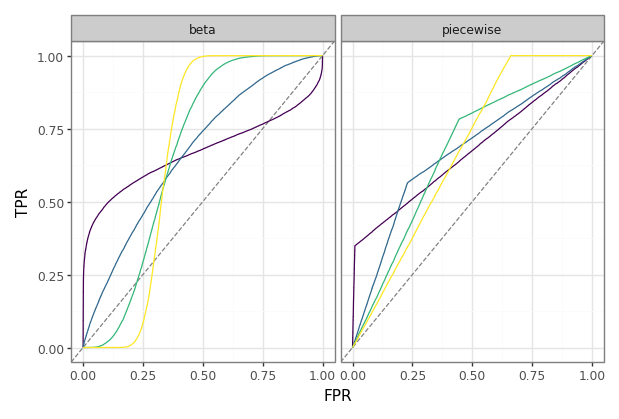

In [24]:
# compute and display roc curve
df_roc = (
    df.sort("score", descending=True)
    .with_columns(
        neg_target=1 - pl.col("target"),
        neg_target_ttl=(1 - pl.col("target")).sum().over("id", "method"),
        pos_target=pl.col("target"),
        pos_target_ttl=pl.col("target").sum().over("id", "method"),
    )
    .with_columns(
        cum_fpr=pl.col("neg_target").cum_sum().over("id", "method")
        / pl.col("neg_target_ttl"),
        cum_tpr=pl.col("pos_target").cum_sum().over("id", "method")
        / pl.col("pos_target_ttl"),
    )
)

p = ggplot(df_roc)
p += aes(x="cum_fpr", y="cum_tpr", color="id", group="id")
p += geom_abline(intercept=0, slope=1, color="grey", linetype="dashed")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p += labs(x="FPR", y="TPR")
p.save("aucs.png")
p

## Metrics

Similarly, the different datasets show dramatic differences in precision, recall, and other model evaluation metrics.

In [25]:
df_metrics = (
    df.group_by("method", "id")
    .agg(metrics=pds.query_binary_metrics("target", "score", 0.9))
    .unnest("metrics")
    .sort('method','id')
)
df_metrics

method,id,precision,recall,f,avg_precision,roc_auc
str,i32,f64,f64,f64,f64,f64
"""beta""",0,0.83191,0.493448,0.619462,0.768178,0.669964
"""beta""",1,0.688152,0.224007,0.337992,0.642299,0.668905
"""beta""",2,0.153714,0.01797,0.032178,0.552798,0.671039
"""beta""",3,0.0,0.0,NaN,0.539533,0.670067
"""piecewise""",0,0.807316,0.40883,0.542789,0.741399,0.671911
"""piecewise""",1,0.710245,0.248535,0.36822,0.6518,0.668542
"""piecewise""",2,0.630259,0.174282,0.273058,0.618796,0.668261
"""piecewise""",3,0.594003,0.149854,0.23933,0.598817,0.668536


The range of potential values for each metric is quite material. 

In [26]:
(
    df_metrics
    .drop("method", "id")
    .select(
        (cs.all().max() - cs.all().min()).name.prefix("rng__"),
    )
)

rng__precision,rng__recall,rng__f,rng__avg_precision,rng__roc_auc
f64,f64,f64,f64,f64
0.83191,0.493448,0.587284,0.228645,0.00365


## Lift Charts

The event rate by quantile also shows vastly different patterns for each datset.

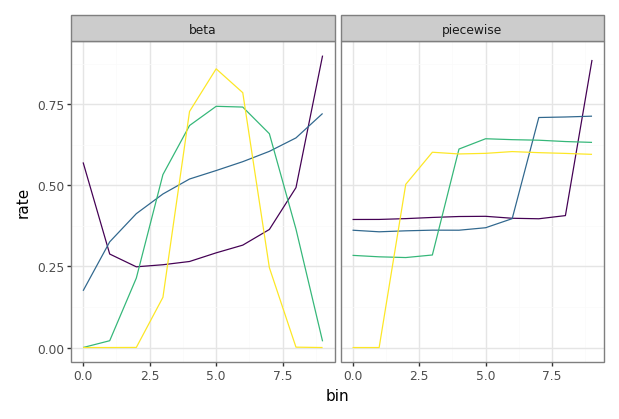

In [27]:
# visualize lift curves
df_lift = df.group_by(
    "method",
    "id",
    bin=pl.col("score")
    .qcut(10, labels=arange(10).astype(str))
    .cast(pl.String)
    .cast(pl.Int16),
).agg(rate=pl.col("target").mean())

p = ggplot(df_lift)
p += aes(x="bin", y="rate", color="id", group="id")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p